In [504]:
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [505]:
dataset = pd.read_csv("Data/Dataset 2.csv")
dataset.head(1)

,observation_date,UNRATE
0,1948-01-01,3.4


### 1. Data Preparation 
- Check the time index for duplicates, missing timestamps, and irregularities. 
- Check for missing observations and explain how they are handled. 
- Check for obvious data-quality issues and document any preprocessing. 
- Ensure that the observations are correctly ordered chronologically. 
- If a transformation is applied, explain why it is appropriate.

In [506]:
print(f"Number of duplicated rows: {dataset.duplicated().sum()}")
print(f"Number of empty rows: {dataset.isna().values.sum()}")

for column in dataset.columns:
    
    print(f"Data type of '{column}' column: {dataset[column].dtype}")

Number of duplicated rows: 0
Number of empty rows: 1
Data type of 'observation_date' column: object
Data type of 'UNRATE' column: float64


In [507]:
dataset.describe()

,UNRATE
count,942.000000
mean,5.656157
std,1.703930
min,2.500000
25%,4.300000
50%,5.500000
75%,6.700000
max,14.800000


In [508]:
new_names = {}

for column in dataset.columns:
    
    new_names[column] = column.lower()
    
dataset = dataset.rename(columns = new_names)

In [509]:
dataset["observation_date"] = pd.to_datetime(dataset["observation_date"])
dataset["unrate"] = dataset["unrate"].astype("float32").round(1)

In [510]:
dataset = dataset.set_index("observation_date" , drop = True)
dataset.head()

,unrate
observation_date,
1948-01-01,3.4
1948-02-01,3.8
1948-03-01,4.0
1948-04-01,3.9
1948-05-01,3.5


In [511]:
dataset = dataset.dropna()

In [512]:
print(f"Number of duplicated rows: {dataset.duplicated().sum()}")
print(f"Number of empty rows: {dataset.isna().values.sum()}")

for column in dataset.columns:
    
    print(f"Data type of '{column}' column: {dataset[column].dtype}")
    
print(f"Data type of 'observation_date' column: {dataset.index.dtype}")

Number of duplicated rows: 859
Number of empty rows: 0
Data type of 'unrate' column: float32
Data type of 'observation_date' column: datetime64[ns]


#### Summary

- Loaded the `UNRATE` (unemployment rate) dataset from CSV and previewed its structure.
- Checked for duplicate rows and missing values, and inspected column data types.
- Used `describe()` to review summary statistics and check for obvious data-quality issues (e.g., out-of-range values).
- Standardized column names to lowercase.
- Converted `observation_date` to `datetime` and `unrate` to `float32` (rounded to 1 decimal) to ensure correct, consistent data types.
- Set `observation_date` as the index so the data is properly ordered as a time series.
- Dropped remaining missing observations.
- Re-verified the cleaned data: no duplicates, no missing values, and correct data types for both the date index and the `unrate` column.

The dataset is now cleaned, chronologically indexed, and ready for further time-series analysis.

### 2. Exploratory Time Series Analysis 
- Plot the original time series. 
- Investigate the series for the components we discussed in the sessions. 
- Use appropriate rolling statistics when useful. 
- Use ACF and PACF plots to investigate temporal dependence.

In [513]:
def plot_series(dataset: pd.DataFrame , column: str , title: str , color: str = "blue") -> None:
    
    plt.figure(figsize = (12 , 4))
    plt.plot(dataset[column] , color = color)
    plt.title(title)
    plt.xlabel(dataset.index.name if dataset.index.name else "Date")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_acf_pacf(dataset: pd.DataFrame , column: str , lags = 30):
    
    fig , axes = plt.subplots(1 , 2 , figsize = (12 , 4))    
    plot_acf(dataset[column].dropna() , lags = lags , ax = axes[0])    
    plot_pacf(dataset[column].dropna() ,lags = lags , ax = axes[1] , method = "ywm")    
    plt.tight_layout()
    plt.show()

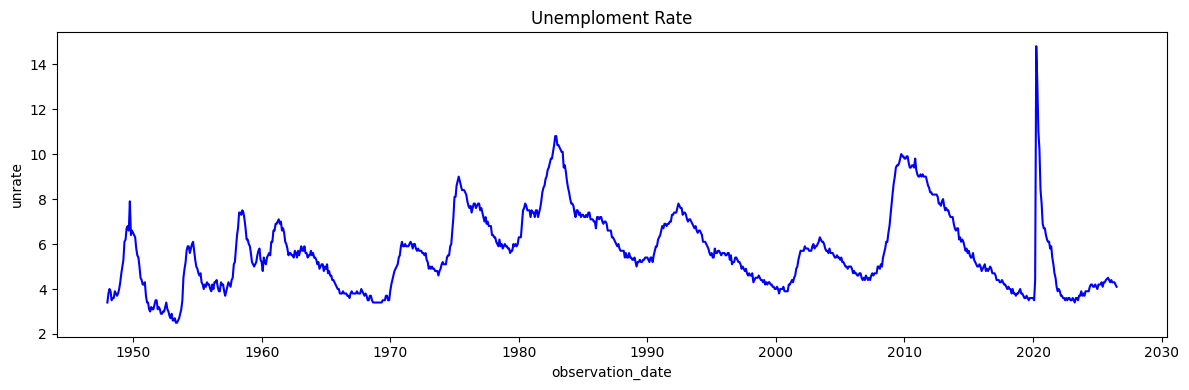

In [515]:
plot_series(dataset , "unrate" , "Unemploment Rate")

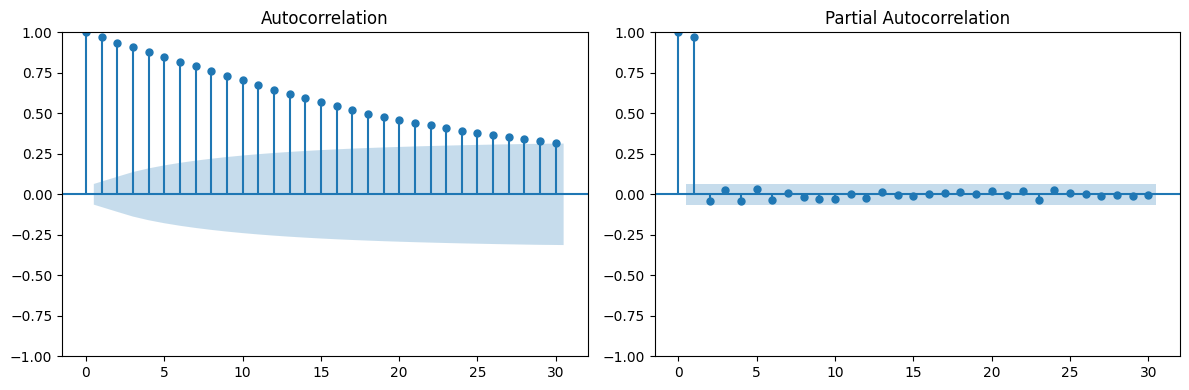

In [516]:
plot_acf_pacf(dataset , "unrate")